In [1]:
#**************************************************************************************************************************************
#                                             Singular-Value Decomposition (SVD)                                                      *
#                                                                                                                                     *
#    This code performs dimensionality reduction using Singular Value Decomposition (SVD) and visualizes the results.                 *
#    This code allows for an understanding of how dimensionality reduction affects the data and provides visualizations to aid        *
#    in the analysis. It's particularly useful for exploring high-dimensional datasets and understanding the underlying structure.    *
#                                                                                                                                     *
#**************************************************************************************************************************************

In [2]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
class SVD:
    @staticmethod
    def svd(X, k=None):
        """
        Perform Singular Value Decomposition (SVD) on the input matrix X using PyTorch.

        Parameters:
          - X (numpy.ndarray): Input matrix of shape (m, n).
          - k (int): Number of top singular values to retain for dimensionality reduction. If None, retains all singular values.

        Returns:
          - U (numpy.ndarray): Left singular vectors of shape (m, k).
          - S (numpy.ndarray): Singular values in descending order of shape (k,).
          - Vt (numpy.ndarray): Right singular vectors of shape (k, n).
        """

        X_tensor = torch.tensor(X, dtype=torch.float32)                                   # Convert numpy array to torch tensor
        U, S, Vt = torch.svd(X_tensor)                                                    # Perform SVD
        U = U.numpy()
        S = S.numpy()
        Vt = Vt.numpy().T

        if k is not None:
            U = U[:, :k]
            S = S[:k]
            Vt = Vt[:k, :]

        return U, S, Vt


In [4]:
def banner():
    print("""
***************************************************************************************************************************
*                                         Singular-Value Decomposition (SVD)                                              *
*                                                                                                                         *
*     Singular Value Decomposition (SVD) is a powerful technique in linear algebra used for dimensionality reduction,     *
*     feature extraction, and data compression. It decomposes a matrix into three matrices: U, S, and Vt, where:          *
*                                                                                                                         *
*             - U: Left singular vectors                                                                                  *
*             - S: Singular values (diagonal matrix)                                                                      *
*             - Vt: Right singular vectors (transposed)                                                                   *
*             SVD is particularly useful for analyzing and visualizing high-dimensional data.                             *
*                                                                                                                         *
*     Usage:                                                                                                              *
*             1. Load your dataset into a pandas DataFrame.                                                               *
*             2. Extract features and labels from the dataset.                                                            *
*             3. Call the 'svd' function with your data matrix X and specify the number of dimensions (k) to retain.      *
*             4. Visualize the results using the provided DimensionalityReductionVisualizer.                              *
*             5. Experiment with different values of k to find the optimal number of dimensions for your analysis.        *
*                                                                                                                         *
***************************************************************************************************************************
  """)


banner()
dataset = pd.read_csv("heart_statlog_cleveland_hungary_final.csv")                       # Load the dataset
X = dataset.drop(columns=["target"]).values                                              # Extract features and labels
U, S, Vt = SVD.svd(X)                                                                    # Perform SVD
k = int(input("\n---> Enter the value of k for dimensionality reduction: "))             # Number of dimensions to retain
U_reduced, S_reduced, Vt_reduced = SVD.svd(X, k=k)                                       # Perform SVD with dimensionality reduction
X_reduced = np.dot(X, Vt_reduced.T)                                                      # Dimensionality reduction


print("\n***************************************************************************************************************************\n")
# Print the results
print("---> Left Singular Vectors (U):\n")
print(U_reduced)
print("\n***************************************************************************************************************************\n")
print("---> Singular Values (S):\n")
print(S_reduced)
print("\n***************************************************************************************************************************\n")
print("---> \nRight Singular Vectors (Vt):\n")
print(Vt_reduced)
print("\n***************************************************************************************************************************\n")
print("---> \nReduced Dataset:\n")
print(X_reduced)



***************************************************************************************************************************
*                                         Singular-Value Decomposition (SVD)                                              *
*                                                                                                                         *
*     Singular Value Decomposition (SVD) is a powerful technique in linear algebra used for dimensionality reduction,     *
*     feature extraction, and data compression. It decomposes a matrix into three matrices: U, S, and Vt, where:          *
*                                                                                                                         *
*             - U: Left singular vectors                                                                                  *
*             - S: Singular values (diagonal matrix)                                                                      *
*      

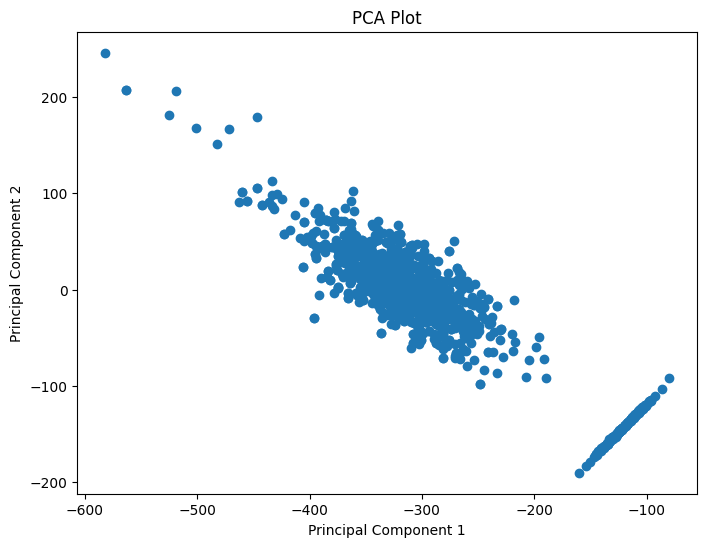

In [5]:
def svd_plot(X_reduced, dimensions=2):
    """
    Plot PCA based on specified dimensions.
    """
    if dimensions not in [2, 3]:
        raise ValueError("Dimensions must be 2 or 3 for PCA plot.")
    plt.figure(figsize=(8, 6))
    if dimensions == 2:
        plt.scatter(X_reduced[:, 0], X_reduced[:, 1])
        plt.xlabel("Principal Component 1")
        plt.ylabel("Principal Component 2")
    elif dimensions == 3:
        ax = plt.axes(projection='3d')
        ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 2])
        ax.set_xlabel("Principal Component 1")
        ax.set_ylabel("Principal Component 2")
        ax.set_zlabel("Principal Component 3")
    plt.title("PCA Plot")
    plt.show()


svd_plot(X_reduced, dimensions=2)                                                       # Generate and display the plots

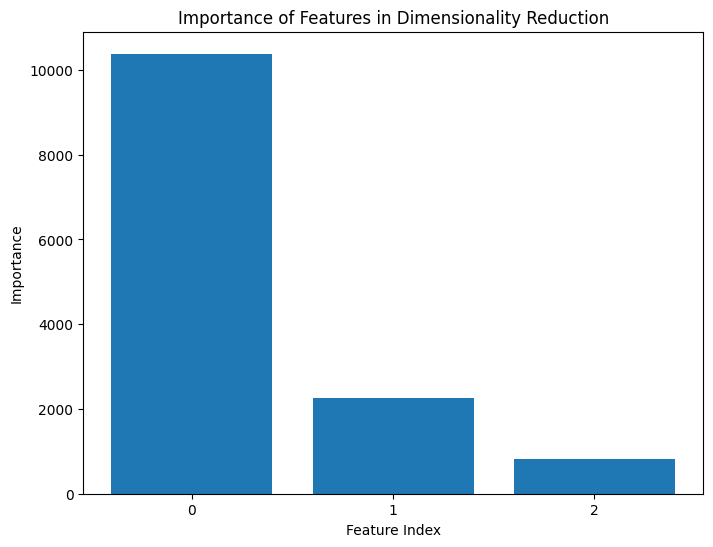

In [6]:
def importance_plot(singular_values, n_features=10):
    """
    Plot the importance of features in dimensionality reduction.
    """
    plt.figure(figsize=(8, 6))
    n_features = min(n_features, len(singular_values))                                   # Ensure we are plotting only as many features as we have
    sorted_indices = np.argsort(singular_values)[::-1]
    top_indices = sorted_indices[:n_features]
    plt.bar(range(n_features), singular_values[top_indices], align='center')
    plt.xlabel("Feature Index")
    plt.ylabel("Importance")
    plt.title("Importance of Features in Dimensionality Reduction")
    plt.xticks(range(n_features), top_indices)                                           # Ensure indices are correctly labeled
    plt.show()


importance_plot(S_reduced, n_features=10)                                                # Generate and display the plots

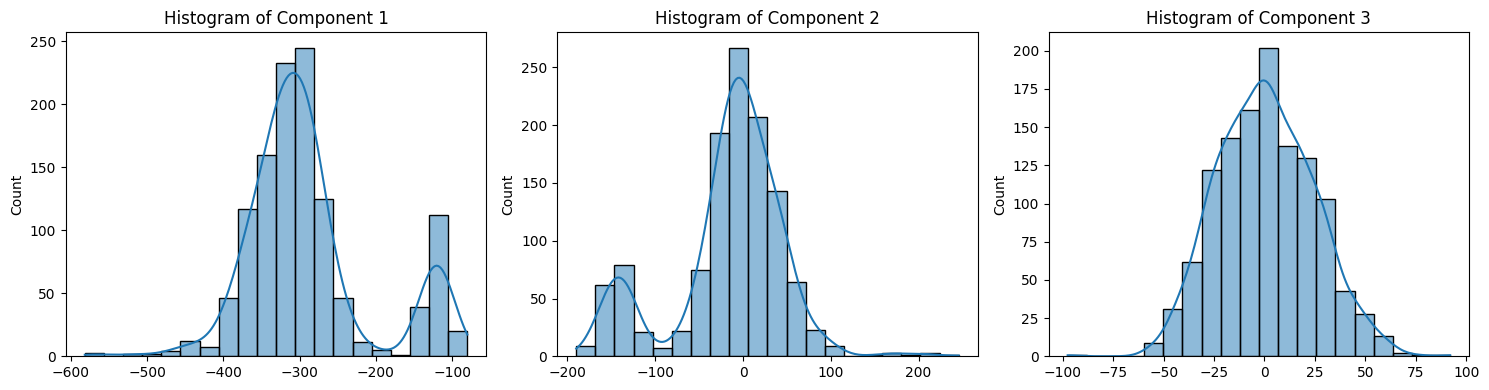

In [7]:
def std_dev_plot(X_reduced):
    """
    Plot the standard deviation of principal components.
    """
    plt.figure(figsize=(15, 4))
    for i in range(X_reduced.shape[1]):
        plt.subplot(1, X_reduced.shape[1], i + 1)
        sns.histplot(X_reduced[:, i], bins=20, kde=True)
        plt.title(f"Histogram of Component {i+1}")
    plt.tight_layout()
    plt.show()



std_dev_plot(X_reduced)                                                                  # Generate and display the plots